In [1]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import re
import cmocean.cm as cmo
import skymapper as skm
import matplotlib.patheffects as PathEffects
import importlib
import healpy as hp
import astropy.units as u
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.cm as cm

from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from mocpy import MOC
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack
from pathlib import Path
import fitsio

from mocpy import MOC
from mocpy import WCS as MOCWCS
from astropy.coordinates import Angle
from astropy.wcs import WCS

%cd /global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/src/statistics/
import corrfiles as cf
%cd ../analysis/
import maps

DESI_ROOT_DR2 = Path(
    "/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP"
)
moc_list = sorted(
    [
        Path(
            "/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/mocs/",
            f"hsc_moc{i+1}.fits",
        )
        for i in range(0, 4)
    ]
)
cmap_hsc = plt.get_cmap("plasma")
cmap_desi = plt.get_cmap("viridis")

/global/cfs/cdirs/desicollab/users/qlavier/desi-y3-hsc/src/statistics
/global/cfs/cdirs/desicollab/users/qlavier/desi-y3-hsc/src/analysis


In [2]:
hsc_bins = np.arange(0.3, 1.6, 0.3)
hsc_bins=np.append(hsc_bins, 2.0)
hsc_bins=np.append(hsc_bins, 2.7)

hsc = fio.FITS(
    "/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/hsc/cat/hscy3_cat_withflags.fits"
)[1].read()

photoz = hsc["dnnz_photoz_best"]
zbin = hsc["z_bin"]
imag = hsc["i_cm_mag"]

In [3]:
caps = ["NGC", "SGC"]
tgts_dr1 = ["BGS_ANY", "LRG", "QSO"]
desi_tgts_dr1 = {
    (tgt, cap): cf.fetch_desi_files(tgt=tgt, version="DR1", cap=cap)
    for tgt in tgts_dr1
    for cap in caps
}

desi_tbls_dr1 = {}
print("Reading DR1 catalogs...")
for tracer in tgts_dr1:
    desi_cat = [desi_tgts_dr1[(tracer, cap)] for cap in caps]
    dt = vstack([Table(fio.read(dc, columns=["RA", "DEC", "Z"])) for dc in desi_cat])
    desi_tbls_dr1[tracer] = dt
desi_dr1 = vstack(list(desi_tbls_dr1.values()))
print(desi_dr1)

Reading DR1 catalogs...
         Z                  RA                 DEC        
------------------- ------------------ -------------------
0.11780978798091779 159.21336539688306   -10.1570784990642
0.18852438367491672 159.31752567050466 -10.126518405884719
0.13939738520826428 157.87076725654435  -9.875451258938376
0.13384342727980247 157.95311366416092   -9.89176181427952
0.13481237197080895 157.95938723949703  -9.900573678838345
 0.3277038731563745  158.0586254092098  -9.883478054340443
 0.2804423196541022  158.0919034157211  -9.885985138196315
 0.1756295118675194 158.09744754077613  -9.948586941938014
0.33523825921833983  158.1320790634476  -9.946322282423829
 0.0658163399193767   158.186134668255  -9.903018240659181
                ...                ...                 ...
  2.701305091515055 349.04407547586106  32.132566637250875
 1.3007878652113634 349.06349661982006  32.370892201204896
 1.9337047152432962 349.06726086266224    32.3243387421514
  1.602623121223449  349.0735066

In [4]:
def sample_desi_on_moc(desi_catalog: Table, desi_tbls: dict):
    coords_desi = SkyCoord(
        ra=desi_catalog["RA"] * u.deg, dec=desi_catalog["DEC"] * u.deg, frame="icrs"
    )
    tbl_in_moc_n = {k: np.zeros(len(v), dtype=bool) for k, v in desi_tbls.items()}
    desi_in_moc_n = np.zeros(len(coords_desi), dtype=bool)
    for mocf in moc_list:
        print(f"Processing MOC file: {mocf}")
        moc = MOC.from_fits(mocf)
        desi_in_moc_n |= moc.contains_skycoords(coords_desi)
        for k, v in desi_tbls.items():
            tbl_in_moc_n[k] |= moc.contains_skycoords(
                SkyCoord(ra=v["RA"] * u.deg, dec=v["DEC"] * u.deg, frame="icrs")
            )
    desi_in_hsc = desi_catalog[np.flatnonzero(desi_in_moc_n)]
    tbl_in_hsc = {k: v[np.flatnonzero(tbl_in_moc_n[k])] for k, v in desi_tbls.items()}
    return desi_in_hsc, tbl_in_hsc

In [5]:
desi_in_hsc_dr1, tbl_in_hsc_dr1 = sample_desi_on_moc(desi_dr1, desi_tbls_dr1)

Processing MOC file: /global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/mocs/hsc_moc1.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/mocs/hsc_moc2.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/mocs/hsc_moc3.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/mocs/hsc_moc4.fits


In [6]:
## QSO differences in HSC between DESI DR1 and DR2 (density), appendix B
arcmin_hsc_area = 416 * 3600
print(f"{len(tbl_in_hsc_dr1['QSO'])/arcmin_hsc_area:.4f}")

0.0471


In [7]:
## general settings for the two following plots
total_area_deg2 = 416  # effective area of HSC in deg^2
show_nocalib = False  # whether to show the HSC histograms without calibration aswell

tracer_trad = {
    "BGS_ANY": "BGS",
    "LRG": "LRG",
    # "ELG_LOPnotqso": "ELG-LOP",
    # "ELGnotqso": "ELG-LOP+VLO",
    "QSO": "QSO",
}
dr_styles = {
    "DR1": {"linestyle": "--", "color_total": "orange", "alpha": 1, "linewidth": 2.2},
}

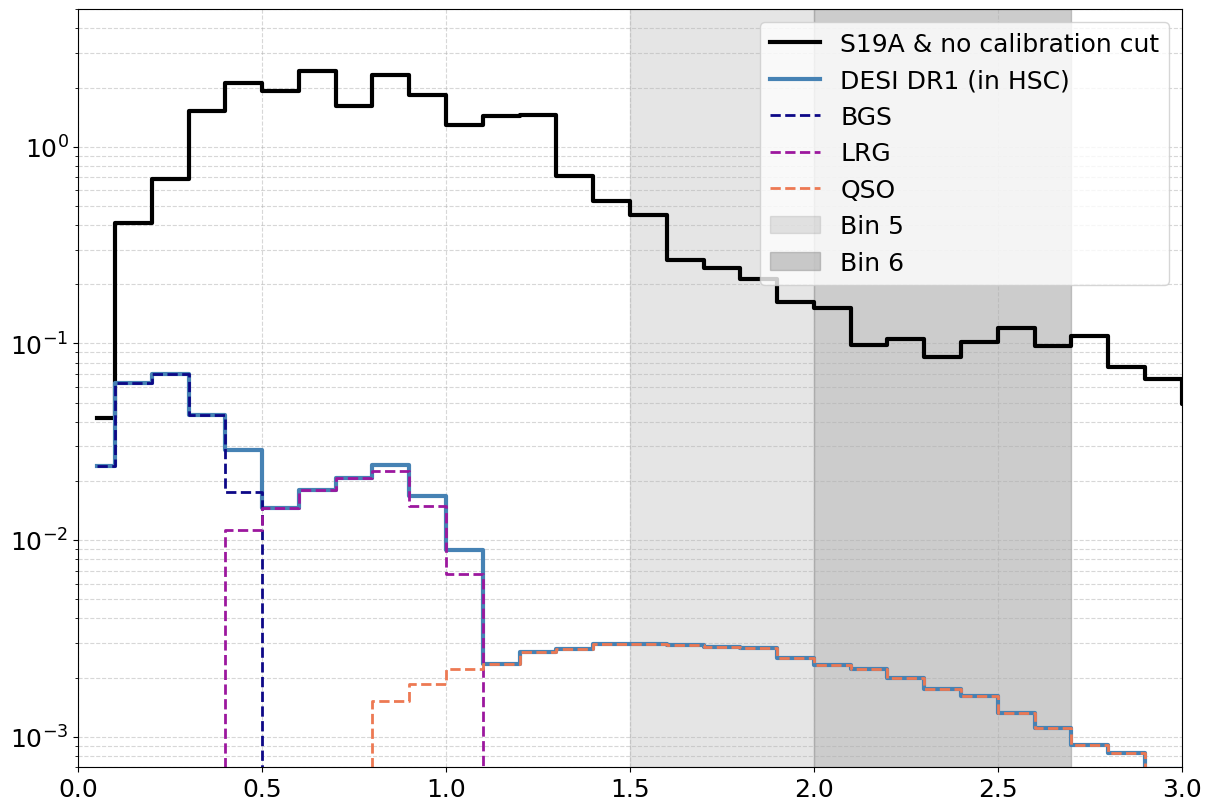

In [10]:
plt.rcParams.update({"font.size": 18})
fig, ax = plt.subplots(constrained_layout=True, figsize=(12, 8))
global_bins = np.arange(0, 7.1, 0.1)
bin_centers = (global_bins[:-1] + global_bins[1:]) / 2
dz_bin = global_bins[1] - global_bins[0]
norm_per_bin = total_area_deg2 * 3600

counts_total, _ = np.histogram(photoz, bins=global_bins)
counts_total_per_area = counts_total / norm_per_bin

ax.step(
    bin_centers,
    counts_total_per_area,
    where="mid",
    color="black",#cmap_hsc(0.2),
    linewidth=3, 
    linestyle="-",
    label="S19A & no calibration cut"
)

dr_data = {
    "DR1": (tgts_dr1, desi_in_hsc_dr1, tbl_in_hsc_dr1),
}

tracers_plotted = set()

for dr_name, (tgts, desi_in_moc, tbls_in_moc) in dr_data.items():
    dr_style = dr_styles[dr_name]

    counts_desi, _ = np.histogram(desi_in_moc["Z"], bins=global_bins)
    counts_desi_per_area = counts_desi / norm_per_bin
    ax.step(
        bin_centers,
        counts_desi_per_area,
        where="mid",
        color="steelblue",#dr_style["color_total"],
        label=f"DESI DR1 (in HSC)",
        linewidth=3, 
        linestyle="-",
        alpha=dr_style["alpha"],
    )

cmap_desi = plt.get_cmap("plasma")
for dr_name, (tgts, desi_in_moc, tbls_in_moc) in dr_data.items():
    dr_style = dr_styles[dr_name]

    for tracer_key, tbl in tbls_in_moc.items():
        tracer_display = tracer_trad.get(tracer_key, tracer_key)
        counts_target, _ = np.histogram(tbl["Z"], bins=global_bins)
        counts_target_per_area = counts_target / norm_per_bin

        tracer_idx = (
            list(tracer_trad.keys()).index(tracer_key)
            if tracer_key in tracer_trad
            else 0
        )
        color = cmap_desi((tracer_idx) / (len(tracer_trad)))
        if tracer_key not in tracers_plotted:
            label = tracer_display
            tracers_plotted.add(tracer_key)
        else:
            label = None

        ax.step(
            bin_centers,
            counts_target_per_area,
            where="mid",
            color=color,
            label=label,
            linewidth=2, 
            linestyle=dr_style["linestyle"],
            alpha=dr_style["alpha"],
        )

ax.axvspan(1.5, 2.0, color="gray", alpha=0.2, label="Bin 5")
ax.axvspan(2.0, 2.7, color="gray", alpha=0.4, label="Bin 6")

ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.set_xlim(0.0, 3.0)
ax.set_yscale("log")
ax.set_ylim(7e-4, 5)
plt.savefig("/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/src/statistics/scripts_nz/paper_figs/density_tracers.png", dpi=300)
plt.show()